# ETL y Construcción de la Red Biogeográfica de Pangea

*Computación Social y Personalización — Grado en Ciencia de Datos e Inteligencia Artificial*

---

**Objetivo:** Construir una red de co-ocurrencia fósil a partir de la base de datos [Paleobiology Database (PBDB)](https://paleobiodb.org/) para modelar las relaciones biogeográficas entre yacimientos terrestres del Triásico (período de Pangea). La pipeline cubre la carga del dataset, la limpieza y el filtrado geológico, la construcción de un grafo bipartito (Yacimiento–Género), su proyección a una red unipartita ponderada, la poda de señal débil, y la detección de comunidades con el algoritmo de Louvain.

**Salida:** `pangea_comunidades_louvain.gexf` — grafo podado con comunidades etiquetadas, listo para análisis topológico y visualización en Gephi.

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
import networkx.algorithms.community as nx_comm
import geopandas as gpd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

---
## 1. Carga y Exploración Inicial

El dataset proviene de PBDB y contiene registros de ocurrencias fósiles con más de 70 columnas (taxonomía, cronología, geolocalización, litología, etc.). Las primeras 14 filas del CSV son metadatos de la descarga, por lo que se omiten con `skiprows=14`.

In [2]:
ruta_csv = '../data/pbdb_data.csv'
df_raw = pd.read_csv(ruta_csv, low_memory=False, skiprows=14)

print(f"Dataset crudo: {df_raw.shape[0]} registros x {df_raw.shape[1]} columnas")
df_raw.head(3)

Dataset crudo: 108123 registros x 91 columnas


,occurrence_no,record_type,reid_no,flags,collection_no,identified_name,identified_rank,identified_no,difference,accepted_name,accepted_attr,accepted_rank,accepted_no,early_interval,late_interval,max_ma,min_ma,reference_no,lng,lat,cc,state,county,latlng_basis,latlng_precision,altitude_value,altitude_unit,geogscale,geogcomments,protected,cx_int_no,formation,geological_group,member,formation.1,geological_group.1,member.1,stratscale,zone,zone_type,localsection,localbed,localbedunit,localorder,regionalsection,regionalbed,regionalbedunit,regionalorder,stratcomments,lithdescript,lithology1,lithadj1,lithification1,minor_lithology1,fossilsfrom1,lithology2,lithadj2,lithification2,minor_lithology2,fossilsfrom2,lithdescript.1,lithology1.1,lithadj1.1,lithification1.1,minor_lithology1.1,fossilsfrom1.1,lithology2.1,lithadj2.1,lithification2.1,minor_lithology2.1,fossilsfrom2.1,environment,tectonic_setting,geology_comments,occurrence_comments,authorizer_no,enterer_no,modifier_no,updater_no,authorizer,enterer,modifier,updater,created,modified,updated,paleomodel,geoplate,paleoage,paleolng,paleolat
0,128932,occ,NaN,NaN,10642,Neocalamites sp.,genus,288242,NaN,Neocalamites,NaN,genus,288242.0,Late Triassic,NaN,237.0,201.4,3945,-105.783333,35.200001,US,New Mexico,Santa Fe,based on nearby landmark,seconds,NaN,NaN,small collection,Locality about 5.6 km north of White Lakes and...,NaN,44,Carita Creek,NaN,NaN,Carita Creek,NaN,NaN,bed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The Upper Triassic strata in the White Lakes-L...,Flora occurs in a bed of soft white to yellowi...,mudstone,"flute casts,yellow",poorly lithified,NaN,Y,NaN,NaN,NaN,NaN,NaN,Flora occurs in a bed of soft white to yellowi...,mudstone,"flute casts,yellow",poorly lithified,NaN,Y,NaN,NaN,NaN,NaN,NaN,fluvial indet.,NaN,NaN,NaN,15,62,174,NaN,H. Sims,J. Allen,J. Cassara,NaN,2001-06-08 06:53:35,2004-03-09 16:49:51,NaN,gplates,101,mid,-34.17,10.22
1,128933,occ,NaN,NaN,10642,Brachyphyllum comancheanum n. sp.,species,404536,NaN,Brachyphyllum comancheanum,NaN,species,404536.0,Late Triassic,NaN,237.0,201.4,3945,-105.783333,35.200001,US,New Mexico,Santa Fe,based on nearby landmark,seconds,NaN,NaN,small collection,Locality about 5.6 km north of White Lakes and...,NaN,44,Carita Creek,NaN,NaN,Carita Creek,NaN,NaN,bed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The Upper Triassic strata in the White Lakes-L...,Flora occurs in a bed of soft white to yellowi...,mudstone,"flute casts,yellow",poorly lithified,NaN,Y,NaN,NaN,NaN,NaN,NaN,Flora occurs in a bed of soft white to yellowi...,mudstone,"flute casts,yellow",poorly lithified,NaN,Y,NaN,NaN,NaN,NaN,NaN,fluvial indet.,NaN,NaN,Robust cuticle and protected sunken stomata,15,62,174,NaN,H. Sims,J. Allen,J. Cassara,NaN,2001-06-08 06:53:35,2004-03-09 16:49:51,NaN,gplates,101,mid,-34.17,10.22
2,128934,occ,NaN,NaN,10642,Masculostrobus lafonii n. sp.,species,404537,NaN,Masculostrobus lafonii,NaN,species,404537.0,Late Triassic,NaN,237.0,201.4,3945,-105.783333,35.200001,US,New Mexico,Santa Fe,based on nearby landmark,seconds,NaN,NaN,small collection,Locality about 5.6 km north of White Lakes and...,NaN,44,Carita Creek,NaN,NaN,Carita Creek,NaN,NaN,bed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,The Upper Triassic strata in the White Lakes-L...,Flora occurs in a bed of soft white to yellowi...,mudstone,"flute casts,yellow",poorly lithified,NaN,Y,NaN,NaN,NaN,NaN,NaN,Flora occurs in a bed of soft white to yellowi...,mudstone,"flute casts,yellow",poorly lithified,NaN,Y,NaN,NaN,NaN,NaN,NaN,fluvial indet.,NaN,NaN,Cones absent of large quantities of pollen,15,62,174,NaN,H. Sims,J. Allen,J. Cassara,NaN,2001-06-08 06:53:35,2004-03-09 16:49:51,NaN,gplates,101,mid,-34.17,10.22


De las 70+ columnas, seleccionamos únicamente las variables relevantes para construir la red biogeográfica. Cada fila representa una **ocurrencia fósil**: un género taxonómico encontrado en un yacimiento concreto, con sus coordenadas paleotectónicas reconstruidas por el modelo GPlates.

In [3]:
columnas_clave = [
    'collection_no',   # ID del yacimiento (nodo del grafo bipartito)
    'accepted_name',   # Nombre científico aceptado ("Tyrannosaurus rex")
    'accepted_rank',   # Nivel taxonómico (genus, species, etc.)
    'paleolat',        # Latitud reconstruida en Pangea (modelo GPlates)
    'paleolng',        # Longitud reconstruida en Pangea
    'environment',     # Ambiente deposicional (fluvial, marine shelf, etc.)
    'geoplate'         # Placa tectónica asignada por GPlates
]

df = df_raw[columnas_clave].copy()

print(f"Dimensiones tras selección de variables: {df.shape[0]} hallazgos x {df.shape[1]} variables\n")

nulos_pct = (df.isnull().sum() / len(df)) * 100
print("Porcentaje de valores nulos por columna:")
print(nulos_pct.round(2).astype(str) + "%")

Dimensiones tras selección de variables: 108123 hallazgos x 7 variables

Porcentaje de valores nulos por columna:
collection_no     0.0%
accepted_name    2.35%
accepted_rank    2.35%
paleolat         2.46%
paleolng         2.46%
environment       5.7%
geoplate          0.0%
dtype: object


---
## 2. Limpieza de Datos

### 2.1 Tratamiento de nulos

Las columnas estructurales (`collection_no`, `accepted_name`, `paleolat`, `paleolng`) no admiten imputación: no tiene sentido rellenar una coordenada paleotectónica con la media (destruiría la geolocalización) ni inventar un nombre taxonómico. Los registros con nulos en estas columnas se eliminan.

### 2.2 Extracción del género taxonómico

El campo `accepted_name` contiene nombres binomiales ("*Coelophysis bauri*") y nombres a nivel de género ("*Coelophysis*"). Para homogeneizar la granularidad taxonómica, extraemos siempre la **primera palabra** como nombre de género. Además, filtramos prefijos taxonómicos informales (`cf.`, `aff.`, `ex gr.`) que indicarían identificaciones inciertas.

In [4]:
# Eliminamos registros con nulos en columnas estructurales
df_clean = df.dropna(subset=['collection_no', 'accepted_name', 'paleolat', 'paleolng']).copy()

# Extraemos el género (primera palabra del nombre binomial)
df_clean['genero'] = df_clean['accepted_name'].apply(lambda x: str(x).split()[0])

# Filtramos prefijos taxonómicos informales que no son géneros reales
prefijos_invalidos = {'cf.', 'aff.', 'ex', 'nr.', '"', 'nan'}
df_clean = df_clean[~df_clean['genero'].isin(prefijos_invalidos)]

print(f"Registros tras limpieza de nulos y géneros inválidos: {len(df_clean)} (de {len(df)})")
print(f"Reducción: {((1 - len(df_clean)/len(df)) * 100):.2f}%")

Registros tras limpieza de nulos y géneros inválidos: 102982 (de 108123)
Reducción: 4.75%


### 2.3 Filtrado por ambiente deposicional (terrestre vs. marino)

El objetivo de este trabajo es estudiar la **biogeografía continental** de Pangea. Los organismos marinos tienen patrones de dispersión fundamentalmente distintos (corrientes oceánicas, no barreras terrestres), por lo que incluirlos contaminaría las comunidades detectadas. Filtramos conservando únicamente ambientes deposicionales terrestres.

La lista de ambientes se basa en la clasificación estándar de PBDB:

In [5]:
# Distribución de ambientes antes del filtro
print("Top 15 ambientes deposicionales en el dataset:")
print(df_clean['environment'].value_counts().head(15))

Top 15 ambientes deposicionales en el dataset:
environment
marine indet.                           27314
carbonate indet.                        14585
reef, buildup or bioherm                 7996
open shallow subtidal                    4939
basinal (carbonate)                      4561
terrestrial indet.                       4541
basinal (siliceous)                      4042
shallow subtidal indet.                  4002
lagoonal/restricted shallow subtidal     2230
basinal (siliciclastic)                  2080
slope                                    1933
deep subtidal indet.                     1629
offshore indet.                          1385
offshore                                 1284
deep-water indet.                        1209
Name: count, dtype: int64


In [6]:
biomas_terrestres = [
    'terrestrial', 'fluvial', 'lacustrine', 'alluvial',
    'eolian', 'floodplain', 'delta plain', 'swamp', 'mire'
]

patron = '|'.join(biomas_terrestres)
df_pangea = df_clean[df_clean['environment'].str.contains(patron, case=False, na=False)].copy()

print(f"Registros fósiles terrestres tras el filtro: {len(df_pangea)}")
print(f"Yacimientos únicos: {df_pangea['collection_no'].nunique()}")
print(f"Géneros únicos: {df_pangea['genero'].nunique()}")

Registros fósiles terrestres tras el filtro: 9485
Yacimientos únicos: 2509
Géneros únicos: 2275


---
## 3. Construcción del Grafo Bipartito

Modelamos la relación Yacimiento–Género como un **grafo bipartito** $B = (U, V, E)$, donde:

- $U$ = conjunto de **yacimientos** (`collection_no`), con atributo `bipartite=0`.
- $V$ = conjunto de **géneros fósiles** (`genero`), con atributo `bipartite=1`.
- $(u, v) \in E$ si el género $v$ ha sido encontrado en el yacimiento $u$.

Este grafo bipartito es la estructura intermedia necesaria para obtener la **proyección unipartita** sobre los yacimientos.

In [7]:
B = nx.Graph()

yacimientos = df_pangea['collection_no'].unique()
generos = df_pangea['genero'].unique()

B.add_nodes_from(yacimientos, bipartite=0)
B.add_nodes_from(generos, bipartite=1)

aristas = list(zip(df_pangea['collection_no'], df_pangea['genero']))
B.add_edges_from(aristas)

print(f"Grafo bipartito B:")
print(f"  |U| (Yacimientos) = {len(yacimientos)}")
print(f"  |V| (Géneros)     = {len(generos)}")
print(f"  |E| (Aristas)     = {B.number_of_edges()}")
print(f"  Bipartito válido: {nx.is_bipartite(B)}")

Grafo bipartito B:
  |U| (Yacimientos) = 2509
  |V| (Géneros)     = 2275
  |E| (Aristas)     = 8231
  Bipartito válido: True


## 4. Proyección Unipartita Ponderada

La **proyección ponderada** sobre el conjunto de yacimientos genera un grafo $G = (U, E')$ donde dos yacimientos $u_i, u_j$ están conectados si comparten al menos un género fósil. El peso de la arista es:

$$w(u_i, u_j) = |N(u_i) \cap N(u_j)|$$

donde $N(u)$ es el conjunto de géneros presentes en el yacimiento $u$. Un peso alto indica una fuerte afinidad biogeográfica entre dos yacimientos.

Usamos `bipartite.weighted_projected_graph()` de NetworkX, que implementa esta operación de forma eficiente.

In [8]:
G_pangea = bipartite.weighted_projected_graph(B, yacimientos)

# Eliminamos yacimientos aislados (grado 0: no comparten ningún género con nadie)
G_pangea.remove_nodes_from(list(nx.isolates(G_pangea)))

print(f"Red unipartita G_pangea (pre-poda):")
print(f"  Nodos (Yacimientos): {G_pangea.number_of_nodes()}")
print(f"  Aristas (Conexiones biogeográficas): {G_pangea.number_of_edges()}")

Red unipartita G_pangea (pre-poda):
  Nodos (Yacimientos): 2315
  Aristas (Conexiones biogeográficas): 67297


## 5. Análisis de la Distribución de Pesos y Poda (*Pruning*)

Antes de aplicar algoritmos de detección de comunidades, analizamos la distribución de pesos de las aristas para determinar un umbral de poda que separe **señal** (conexiones biogeográficas reales) de **ruido** (co-ocurrencias espurias por géneros cosmopolitas).

In [9]:
pesos = [d['weight'] for _, _, d in G_pangea.edges(data=True)]
s_pesos = pd.Series(pesos)

print("Estadísticas descriptivas de los pesos de aristas:")
print(s_pesos.describe().round(2))

print(f"\nLas 5 conexiones biogeográficas más fuertes:")
aristas_top = sorted(G_pangea.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
for u, v, d in aristas_top:
    print(f"  Yac. {u} ↔ Yac. {v}: {int(d['weight'])} géneros compartidos")

Estadísticas descriptivas de los pesos de aristas:
count    67297.00
mean         1.22
std          0.89
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         77.00
dtype: float64

Las 5 conexiones biogeográficas más fuertes:
  Yac. 106088 ↔ Yac. 110763: 77 géneros compartidos
  Yac. 105007 ↔ Yac. 106088: 48 géneros compartidos
  Yac. 106090 ↔ Yac. 110763: 44 géneros compartidos
  Yac. 105007 ↔ Yac. 110763: 42 géneros compartidos
  Yac. 106088 ↔ Yac. 106090: 34 géneros compartidos


La distribución muestra que el **75% de las aristas tienen peso 1** (un único género compartido). Estas conexiones son débiles y probablemente reflejan co-ocurrencias de géneros cosmopolitas que aportan más ruido que información biogeográfica.

Aplicamos un umbral de poda eliminando todas las aristas con $w \leq 1$. Este umbral es conservador (la mediana ya es 1), pero prioriza la **especificidad** de las conexiones sobre la cobertura.

> **Nota:** La validación formal de este umbral se realiza en el cuaderno de Análisis Topológico mediante un análisis de sensibilidad (§10).

In [10]:
G_fuerte = G_pangea.copy()

nodos_pre = G_fuerte.number_of_nodes()
aristas_pre = G_fuerte.number_of_edges()

# Eliminamos aristas débiles (peso = 1)
aristas_debiles = [(u, v) for u, v, d in G_fuerte.edges(data=True) if d['weight'] <= 1]
G_fuerte.remove_edges_from(aristas_debiles)

# Eliminamos nodos aislados resultantes (grado 0 rompe cálculos de centralidad)
G_fuerte.remove_nodes_from(list(nx.isolates(G_fuerte)))

nodos_post = G_fuerte.number_of_nodes()
aristas_post = G_fuerte.number_of_edges()

pct_nodos = ((nodos_pre - nodos_post) / nodos_pre) * 100
pct_aristas = ((aristas_pre - aristas_post) / aristas_pre) * 100

print(f"Poda de aristas con peso ≤ 1:")
print(f"  Nodos: {nodos_pre} → {nodos_post} (reducción del {pct_nodos:.1f}%)")
print(f"  Aristas: {aristas_pre} → {aristas_post} (reducción del {pct_aristas:.1f}%)")
print(f"\nEl grafo resultante G_fuerte retiene el núcleo de conexiones biogeográficas")
print(f"con al menos 2 géneros compartidos entre yacimientos.")

Poda de aristas con peso ≤ 1:
  Nodos: 2315 → 943 (reducción del 59.3%)
  Aristas: 67297 → 9210 (reducción del 86.3%)

El grafo resultante G_fuerte retiene el núcleo de conexiones biogeográficas
con al menos 2 géneros compartidos entre yacimientos.


---
## 6. Enriquecimiento con Datos Geográficos

Inyectamos las paleo-coordenadas y la placa tectónica como atributos de cada nodo del grafo. Estos atributos serán necesarios para la visualización geográfica y el análisis de sesgo de muestreo.

In [11]:
dict_lat = df_pangea.set_index('collection_no')['paleolat'].to_dict()
dict_lng = df_pangea.set_index('collection_no')['paleolng'].to_dict()
dict_placa = df_pangea.set_index('collection_no')['geoplate'].to_dict()

nx.set_node_attributes(G_fuerte, dict_lat, 'paleolat')
nx.set_node_attributes(G_fuerte, dict_lng, 'paleolng')
nx.set_node_attributes(G_fuerte, dict_placa, 'geoplate')

# Verificación
nodo_ejemplo = list(G_fuerte.nodes())[0]
print(f"Ejemplo — Nodo {nodo_ejemplo}: {G_fuerte.nodes[nodo_ejemplo]}")

Ejemplo — Nodo 10642: {'bipartite': 0, 'paleolat': 10.22, 'paleolng': -34.17, 'geoplate': '101'}


---
## 7. Detección de Comunidades: Algoritmo de Louvain

Aplicamos el **algoritmo de Louvain** (Blondel et al., 2008) para particionar la red en comunidades que maximicen la **modularidad** $Q$:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

donde $A_{ij}$ es el peso de la arista, $k_i$ el grado ponderado del nodo $i$, $m$ la suma total de pesos, y $\delta(c_i, c_j) = 1$ si $i$ y $j$ pertenecen a la misma comunidad.

Un valor de $Q > 0.3$ se considera indicativo de estructura modular significativa (Newman, 2004). En nuestro contexto, cada comunidad representaría un **macro-bioma** del Triásico: un grupo de yacimientos que comparten una fauna fósil característica.

> **Nota:** La comparación con otros algoritmos (Girvan-Newman, Greedy Modularity, InfoMap) y el análisis de sensibilidad del parámetro de resolución se realizan en el cuaderno de Análisis Topológico.

In [12]:
print("Ejecutando algoritmo de Louvain (resolución γ = 1.0)...")

comunidades = nx_comm.louvain_communities(G_fuerte, weight='weight', resolution=1.0, seed=42)
modularidad = nx_comm.modularity(G_fuerte, comunidades, weight='weight')

print(f"\nResultados:")
print(f"  Comunidades (Biomas) detectadas: {len(comunidades)}")
print(f"  Modularidad Q = {modularidad:.4f}")

if modularidad > 0.3:
    print(f"  Q > 0.3 → Estructura altamente modular. Pangea presentaba biomas diferenciados.")
else:
    print(f"  Q ≤ 0.3 → Estructura débilmente modular. Mezcla global de especies.")

# Distribución de tamaños de comunidades
print(f"\nTamaño de las 5 comunidades más grandes:")
for i, c in enumerate(sorted(comunidades, key=len, reverse=True)[:5]):
    print(f"  Comunidad {i}: {len(c)} yacimientos")

Ejecutando algoritmo de Louvain (resolución γ = 1.0)...

Resultados:
  Comunidades (Biomas) detectadas: 34
  Modularidad Q = 0.7180
  Q > 0.3 → Estructura altamente modular. Pangea presentaba biomas diferenciados.

Tamaño de las 5 comunidades más grandes:
  Comunidad 0: 248 yacimientos
  Comunidad 1: 176 yacimientos
  Comunidad 2: 127 yacimientos
  Comunidad 3: 89 yacimientos
  Comunidad 4: 74 yacimientos


In [13]:
# Etiquetamos cada nodo con su ID de comunidad
dict_comunidades = {}
for id_comunidad, set_nodos in enumerate(comunidades):
    for nodo in set_nodos:
        dict_comunidades[nodo] = id_comunidad

nx.set_node_attributes(G_fuerte, dict_comunidades, 'comunidad_louvain')

# Exportamos el grafo con todos los atributos para análisis posterior y Gephi
ruta_exportacion = '../data/pangea_comunidades_louvain.gexf'
nx.write_gexf(G_fuerte, ruta_exportacion)
print(f"Grafo exportado a: {ruta_exportacion}")

Grafo exportado a: ../data/pangea_comunidades_louvain.gexf


---
## 8. Visualización: Dispersión de Biomas en el Mundo Actual

Proyectamos las comunidades detectadas por Louvain sobre un **mapa del mundo actual** usando las coordenadas modernas de los yacimientos. Si Louvain ha capturado biomas reales del Triásico, esperamos ver que cada comunidad (un color) se dispersa por varios continentes — reflejo de la **fragmentación de Pangea** por la deriva continental.

Visualizamos los **5 macro-biomas** más grandes y agrupamos el resto como micro-comunidades.

In [14]:
# Extraemos las coordenadas actuales de los yacimientos desde el dataset crudo
df_moderno = df_raw[['collection_no', 'lat', 'lng']].dropna().drop_duplicates()

# Unimos las comunidades de Louvain con las coordenadas modernas
df_comunidades = pd.DataFrame(list(dict_comunidades.items()), columns=['collection_no', 'comunidad'])
df_mapa = pd.merge(df_comunidades, df_moderno, on='collection_no', how='inner')

print(f"Yacimientos mapeados: {len(df_mapa)} (de {len(dict_comunidades)})")

Yacimientos mapeados: 943 (de 943)


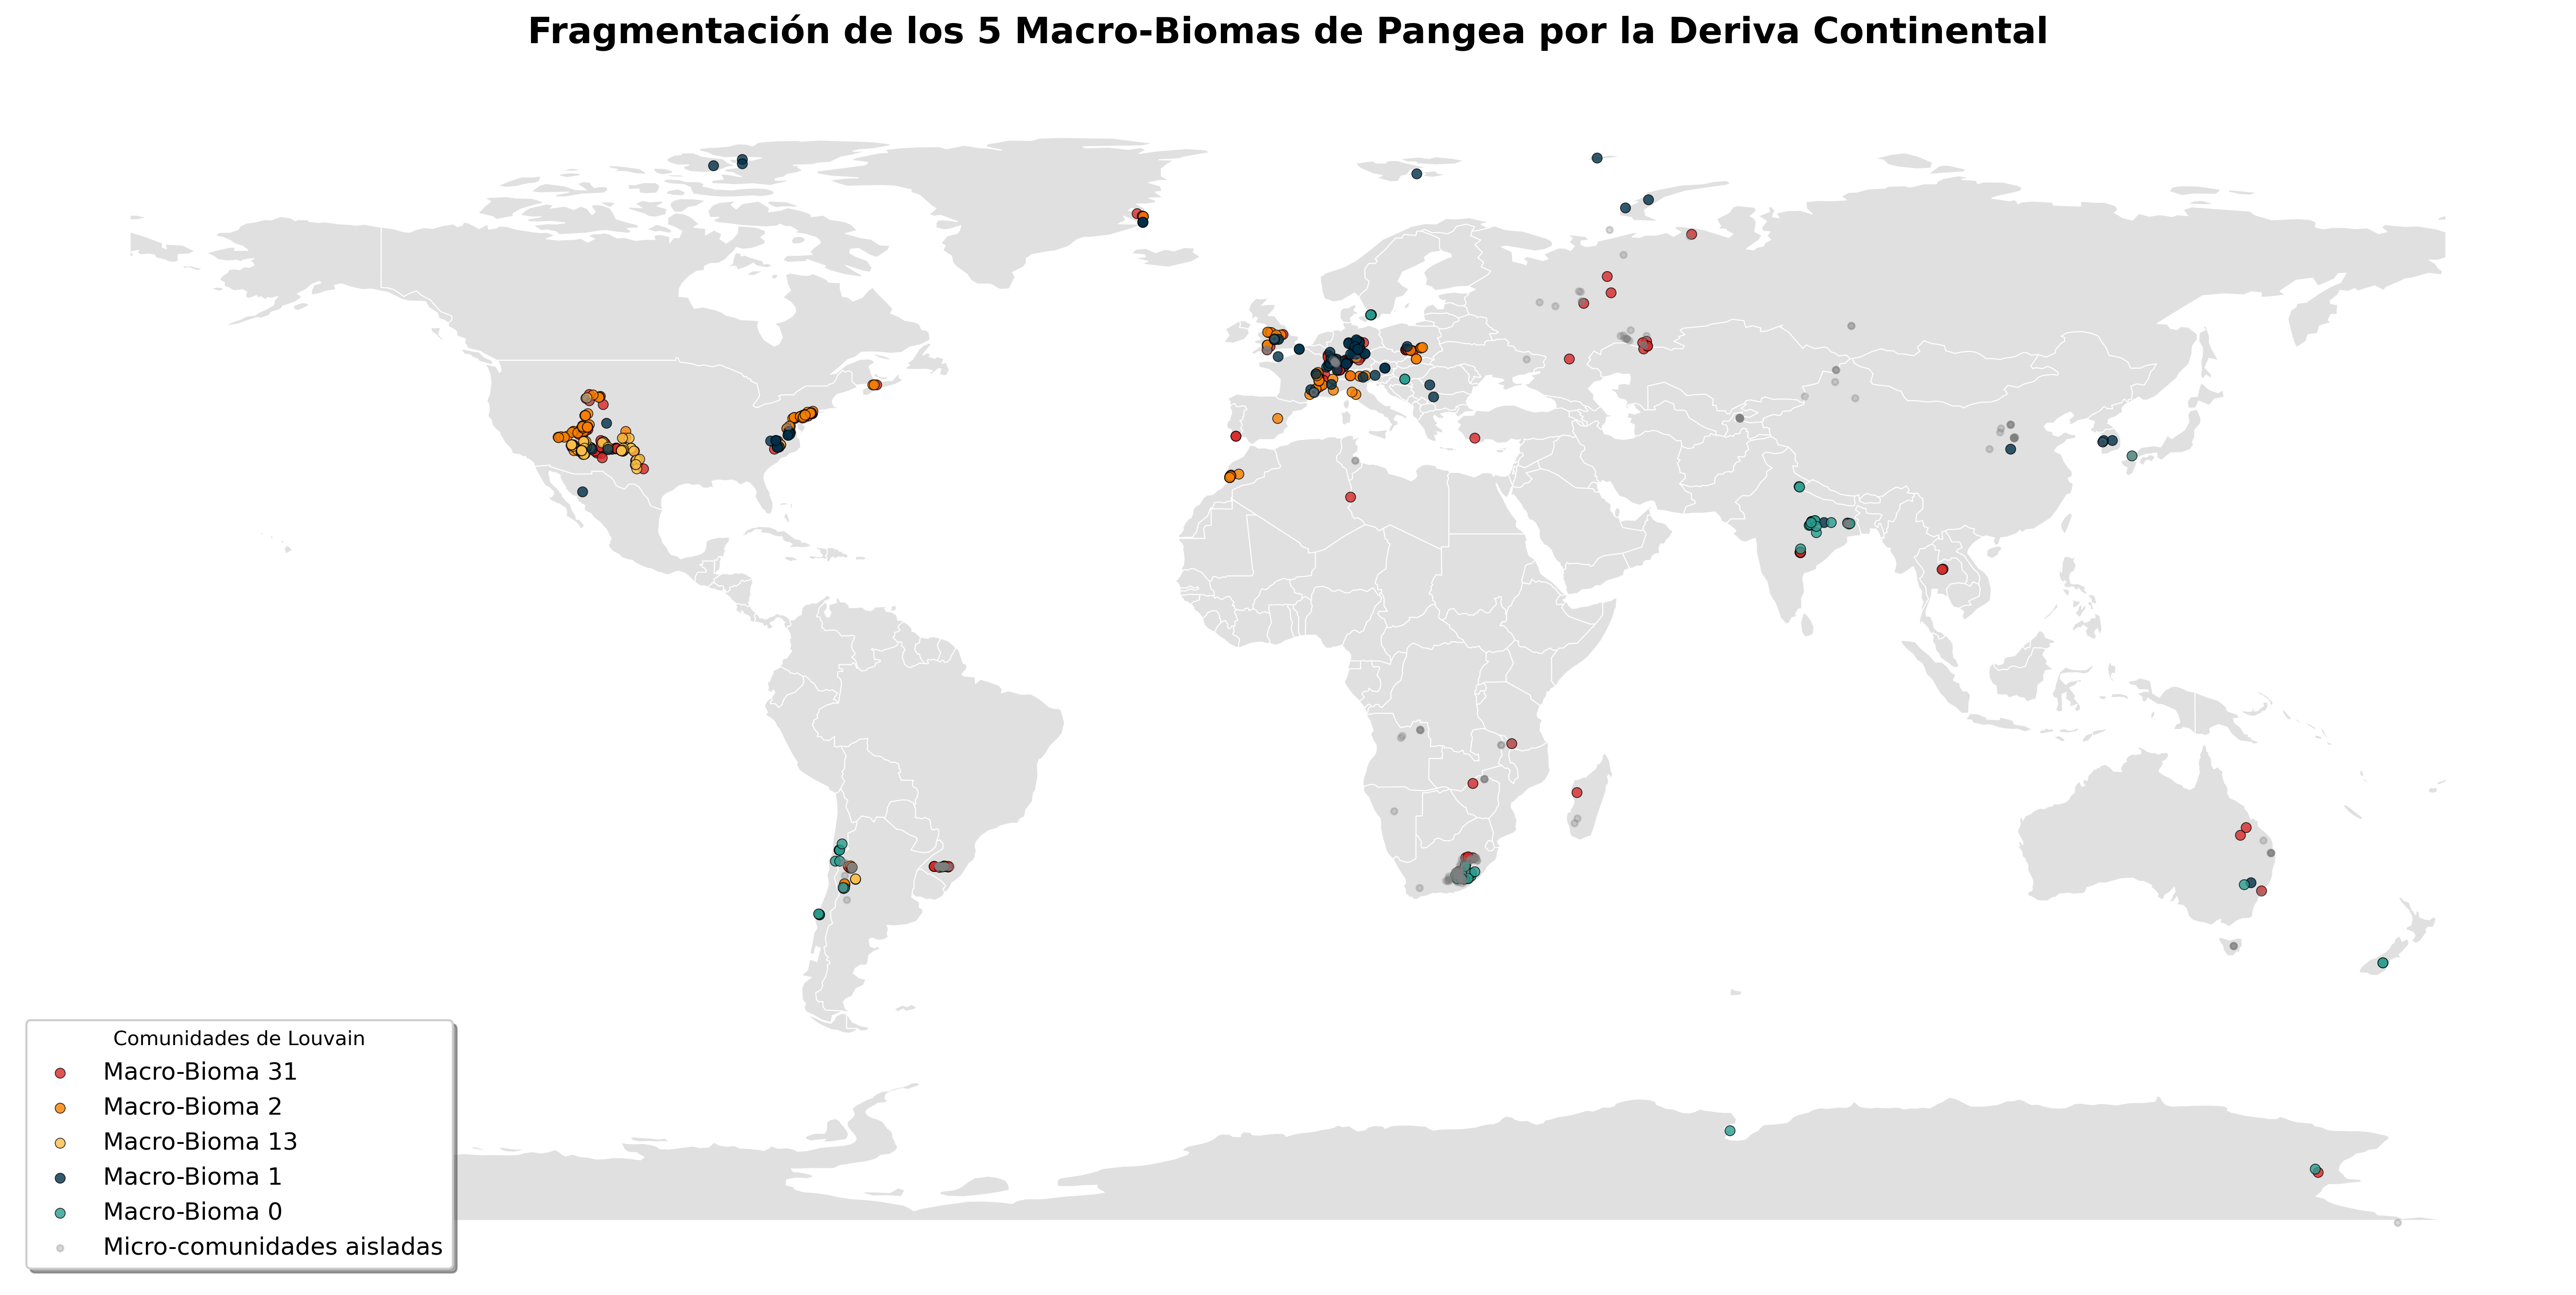

In [ ]:
# Cargamos el mapa base del mundo moderno
url_mapa = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
mundo = gpd.read_file(url_mapa)

fig, ax = plt.subplots(figsize=(18, 10), dpi=300)
mundo.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.5)

# Los 5 macro-biomas más grandes
top_5_biomas = df_mapa['comunidad'].value_counts().head(5).index
colores = ['#d62828', '#f77f00', '#fcbf49', '#003049', '#2a9d8f']

for i, id_bioma in enumerate(top_5_biomas):
    sub = df_mapa[df_mapa['comunidad'] == id_bioma]
    ax.scatter(sub['lng'], sub['lat'],
               color=colores[i], s=25, alpha=0.8,
               edgecolors='black', linewidth=0.4,
               label=f'Macro-Bioma {id_bioma}')

# Micro-comunidades en gris
micro_biomas = df_mapa[~df_mapa['comunidad'].isin(top_5_biomas)]
ax.scatter(micro_biomas['lng'], micro_biomas['lat'],
           color='grey', s=10, alpha=0.3,
           label='Micro-comunidades aisladas')

ax.set_title('Fragmentación de los 5 Macro-Biomas de Pangea por la Deriva Continental',
             fontsize=18, pad=20, weight='bold')
ax.legend(loc='lower left', fontsize=12, frameon=True, shadow=True, title='Comunidades de Louvain')
ax.axis('off')

plt.tight_layout()
plt.show()

---
## Resumen de la Pipeline

| Etapa | Entrada | Salida | Decisión clave |
|:---|:---|:---|:---|
| 1. Carga | CSV PBDB (~70 cols) | 7 columnas seleccionadas | `skiprows=14` para metadatos |
| 2. Limpieza | DataFrame crudo | DataFrame sin nulos + género extraído | `dropna()` (no imputar coordenadas) |
| 3. Filtro terrestre | Todos los ambientes | Solo ambientes continentales | 9 keywords de ambientes terrestres |
| 4. Grafo bipartito | DataFrame filtrado | $B = (U, V, E)$ | `bipartite=0` / `bipartite=1` |
| 5. Proyección | Grafo bipartito $B$ | Red ponderada $G$ | `weighted_projected_graph()` |
| 6. Poda | $G$ con ~67k aristas | $G_{fuerte}$ con ~9k aristas | Umbral: $w > 1$ |
| 7. Comunidades | $G_{fuerte}$ | Partición de Louvain | $\gamma = 1.0$, $Q \approx 0.72$ |
| 8. Exportación | Grafo enriquecido | `.gexf` + mapa PNG | Coordenadas + comunidades |

El análisis topológico completo (métricas de red, comparación con modelos nulos, comparación de algoritmos y sesgo de muestreo) se realiza en el cuaderno complementario: `Analisis_Topologico_Pangea.ipynb`.